In [2]:
# Install required packages
!pip install -q tensorflow pandas matplotlib scikit-learn opencv-python seaborn kaggle

In [3]:
# Import libraries
import os, shutil, random, json, zipfile
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [4]:
# Upload kaggle.json
from google.colab import files
uploaded = files.upload()

# Move to correct location & set permissions
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [5]:
!kaggle datasets download -d charuchaudhry/plantvillage-tomato-leaf-dataset
!unzip -q plantvillage-tomato-leaf-dataset -d /content/raw_data
# Check contents
!ls /content/raw_data

Dataset URL: https://www.kaggle.com/datasets/charuchaudhry/plantvillage-tomato-leaf-dataset
License(s): unknown
plantvillage-tomato-leaf-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/raw_data/plantvillage/Tomato___Bacterial_spot/00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_Bact.Sp 3110.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
plantvillage


In [6]:
# Create project directory structure
!mkdir -p /content/leaf-disease-project/{notebooks,src,data/{raw,processed},models,results,reports}

# Create essential files
!touch /content/leaf-disease-project/README.md
!touch /content/leaf-disease-project/requirements.txt
!touch /content/leaf-disease-project/.gitignore
!touch /content/leaf-disease-project/reports/project_report.md

In [7]:
import os, shutil
from pathlib import Path

# Define paths
RAW_DIR = Path("/content/raw_data/plantvillage")
PROCESSED_DIR = Path("/content/leaf-disease-project/data/processed")
CLASSES = ["Tomato___healthy", "Tomato___Early_blight", "Tomato___Late_blight"]
SPLIT_RATIOS = {"train": 0.7, "val": 0.15, "test": 0.15}

# Create train/val/test subfolders
for split in SPLIT_RATIOS.keys():
    for cls in CLASSES:
        (PROCESSED_DIR / split / cls).mkdir(parents=True, exist_ok=True)

# Helper: Get all image paths per class
def get_images(class_name):
    class_dir = RAW_DIR / class_name
    return [f for f in class_dir.glob("*.JPG") if f.is_file()]

# Split & copy images
for cls in CLASSES:
    images = get_images(cls)
    random.shuffle(images)
    n = len(images)
    train_end = int(SPLIT_RATIOS["train"] * n)
    val_end = train_end + int(SPLIT_RATIOS["val"] * n)

    splits = [
        ("train", images[:train_end]),
        ("val", images[train_end:val_end]),
        ("test", images[val_end:])
    ]

    for split_name, img_list in splits:
        for img_path in img_list:
            dest = PROCESSED_DIR / split_name / cls / img_path.name
            shutil.copy2(img_path, dest)

print("Data organized into train/val/test splits")

Data organized into train/val/test splits


Dataset Summary:

TRAIN:
  Tomato___healthy: 1162 images
  Tomato___Early_blight: 725 images
  Tomato___Late_blight: 1272 images

VAL:
  Tomato___healthy: 353 images
  Tomato___Early_blight: 226 images
  Tomato___Late_blight: 384 images

TEST:
  Tomato___healthy: 353 images
  Tomato___Early_blight: 220 images
  Tomato___Late_blight: 387 images


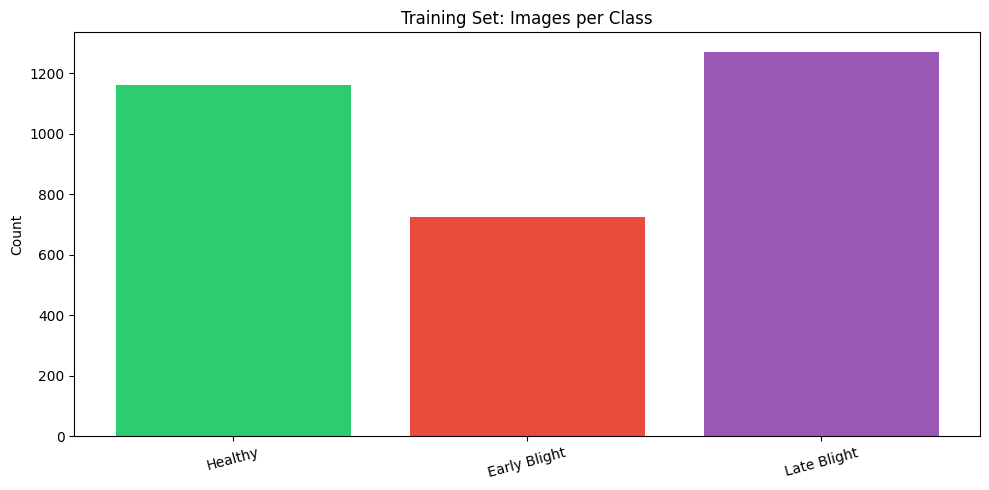

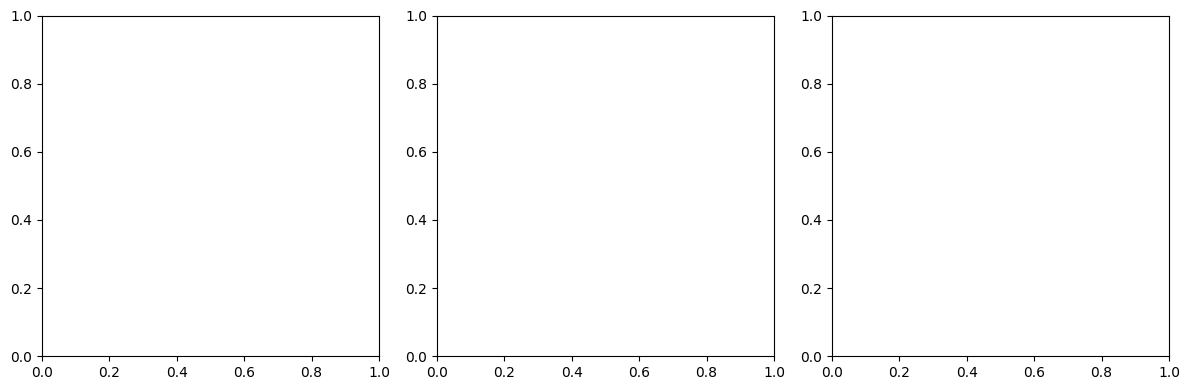

In [8]:
# Count images per class & split
def count_images(base_dir):
    counts = {}
    for split in ["train", "val", "test"]:
        counts[split] = {}
        for cls in CLASSES:
            count = len(list((base_dir / split / cls).glob("*.JPG")))
            counts[split][cls] = count
    return counts

counts = count_images(PROCESSED_DIR)
print("Dataset Summary:")
for split in counts:
    print(f"\n{split.upper()}:")
    for cls, n in counts[split].items():
        print(f"  {cls}: {n} images")

# Visualize class distribution
plt.figure(figsize=(10,5))
classes_clean = [c.replace("Tomato___", "").replace("_", " ").title() for c in CLASSES]
plt.bar(classes_clean, [counts["train"][c] for c in CLASSES], color=['#2ecc71', '#e74c3c', '#9b59b6'])
plt.title("Training Set: Images per Class")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("/content/leaf-disease-project/results/class_distribution.png", dpi=300)
plt.show()

# Show sample images
def plot_samples(class_name, n=3):
    sample_dir = PROCESSED_DIR / "train" / class_name
    samples = list(sample_dir.glob("*.jpg"))[:n]
    fig, axes = plt.subplots(1, n, figsize=(12,4))
    if n==1: axes = [axes]
    for ax, img_path in zip(axes, samples):
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.set_title(class_name.replace("Tomato___","").replace("_"," ").title())
        ax.axis("off")
    plt.tight_layout()
    return fig

# Save one sample grid for report
fig = plot_samples("Tomato___healthy")
plt.savefig("/content/leaf-disease-project/results/sample_healthy.png", dpi=300, bbox_inches="tight")

In [9]:
# Parameters
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = len(CLASSES)
EPOCHS = 15  # Start small; increase if time permits

# Data generators with augmentation (train only)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    PROCESSED_DIR / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    PROCESSED_DIR / "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    PROCESSED_DIR / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Build MobileNetV2 model
base_model = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Freeze base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation="softmax")
], name="tomato_disease_detector")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy", keras.metrics.Precision(), keras.metrics.Recall()]
)

model.summary()

Found 3159 images belonging to 3 classes.
Found 963 images belonging to 3 classes.
Found 960 images belonging to 3 classes.


/tmp/ipykernel_14603/1862355987.py:44: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


Model: "tomato_disease_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,163 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Callbacks
callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint("/content/leaf-disease-project/models/best_model.h5",
                    save_best_only=True, monitor="val_accuracy", mode="max", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

# Train
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

# Save training history
pd.DataFrame(history.history).to_csv("/content/leaf-disease-project/results/training_history.csv", index=False)

Epoch 1/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.6858 - loss: 0.8017 - precision: 0.7366 - recall: 0.6105
Epoch 1: val_accuracy improved from None to 0.86501, saving model to /content/leaf-disease-project/models/best_model.h5



Epoch 1: finished saving model to /content/leaf-disease-project/models/best_model.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 76s 586ms/step - accuracy: 0.7623 - loss: 0.5709 - precision: 0.8062 - recall: 0.7097 - val_accuracy: 0.8650 - val_loss: 0.3391 - val_precision: 0.8831 - val_recall: 0.8318 - learning_rate: 0.0010
Epoch 2/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8255 - loss: 0.4033 - precision: 0.8454 - recall: 0.7985
Epoch 2: val_accuracy improved from 0.86501 to 0.90343, saving model to /content/leaf-disease-project/models/best_model.h5



Epoch 2: finished saving model to /content/leaf-disease-project/models/best_model.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 22s 218ms/step - accuracy: 0.8351 - loss: 0.3872 - precision: 0.8532 - recall: 0.8113 - val_accuracy: 0.9034 - val_loss: 0.2404 - val_precision: 0.9063 - val_recall: 0.8941 - learning_rate: 0.0010
Epoch 3/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.8601 - loss: 0.3331 - precision: 0.8748 - recall: 0.8434
Epoch 3: val_accuracy improved from 0.90343 to 0.90758, saving model to /content/leaf-disease-project/models/best_model.h5



Epoch 3: finished saving model to /content/leaf-disease-project/models/best_model.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - accuracy: 0.8560 - loss: 0.3354 - precision: 0.8676 - recall: 0.8405 - val_accuracy: 0.9076 - val_loss: 0.2405 - val_precision: 0.9108 - val_recall: 0.9013 - learning_rate: 0.0010
Epoch 4/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8713 - loss: 0.3051 - precision: 0.8822 - recall: 0.8554
Epoch 4: val_accuracy improved from 0.90758 to 0.91900, saving model to /content/leaf-disease-project/models/best_model.h5



Epoch 4: finished saving model to /content/leaf-disease-project/models/best_model.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - accuracy: 0.8756 - loss: 0.3001 - precision: 0.8855 - recall: 0.8620 - val_accuracy: 0.9190 - val_loss: 0.2007 - val_precision: 0.9254 - val_recall: 0.9148 - learning_rate: 0.0010
Epoch 5/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8903 - loss: 0.2602 - precision: 0.8980 - recall: 0.8829
Epoch 5: val_accuracy did not improve from 0.91900
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step - accuracy: 0.8930 - loss: 0.2675 - precision: 0.9006 - recall: 0.8835 - val_accuracy: 0.9190 - val_loss: 0.2011 - val_precision: 0.9253 - val_recall: 0.9138 - learning_rate: 0.0010
Epoch 6/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.8839 - loss: 0.2754 - precision: 0.8903 - recall: 0.8733
Epoch 6: val_accuracy improved from 0.91900 to 0.92939, saving model to /content/leaf-disease-project/models/best_model.h5



Epoch 6: finished saving model to /content/leaf-disease-project/models/best_model.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - accuracy: 0.8940 - loss: 0.2528 - precision: 0.9003 - recall: 0.8864 - val_accuracy: 0.9294 - val_loss: 0.1676 - val_precision: 0.9331 - val_recall: 0.9263 - learning_rate: 0.0010
Epoch 7/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.8871 - loss: 0.2808 - precision: 0.8951 - recall: 0.8812
Epoch 7: val_accuracy improved from 0.92939 to 0.93873, saving model to /content/leaf-disease-project/models/best_model.h5



Epoch 7: finished saving model to /content/leaf-disease-project/models/best_model.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 212ms/step - accuracy: 0.8921 - loss: 0.2630 - precision: 0.8992 - recall: 0.8835 - val_accuracy: 0.9387 - val_loss: 0.1562 - val_precision: 0.9395 - val_recall: 0.9356 - learning_rate: 0.0010
Epoch 8/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9096 - loss: 0.2270 - precision: 0.9144 - recall: 0.9038
Epoch 8: val_accuracy did not improve from 0.93873
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 212ms/step - accuracy: 0.9044 - loss: 0.2366 - precision: 0.9097 - recall: 0.8990 - val_accuracy: 0.9252 - val_loss: 0.1854 - val_precision: 0.9278 - val_recall: 0.9211 - learning_rate: 0.0010
Epoch 9/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.8981 - loss: 0.2268 - precision: 0.9012 - recall: 0.8909
Epoch 9: val_accuracy did not improve from 0.93873

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step


Epoch 14: finished saving model to /content/leaf-disease-project/models/best_model.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 21s 212ms/step - accuracy: 0.9231 - loss: 0.1933 - precision: 0.9252 - recall: 0.9202 - val_accuracy: 0.9408 - val_loss: 0.1379 - val_precision: 0.9406 - val_recall: 0.9377 - learning_rate: 5.0000e-04
Epoch 15/15
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9288 - loss: 0.1937 - precision: 0.9309 - recall: 0.9244
Epoch 15: val_accuracy did not improve from 0.94081

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 205ms/step - accuracy: 0.9228 - loss: 0.2051 - precision: 0.9252 - recall: 0.9167 - val_accuracy: 0.9408 - val_loss: 0.1410 - val_precision: 0.9414 - val_recall: 0.9346 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 13.


Test Accuracy: 92.71%
Test Precision: 93.09%
Test Recall: 92.60%


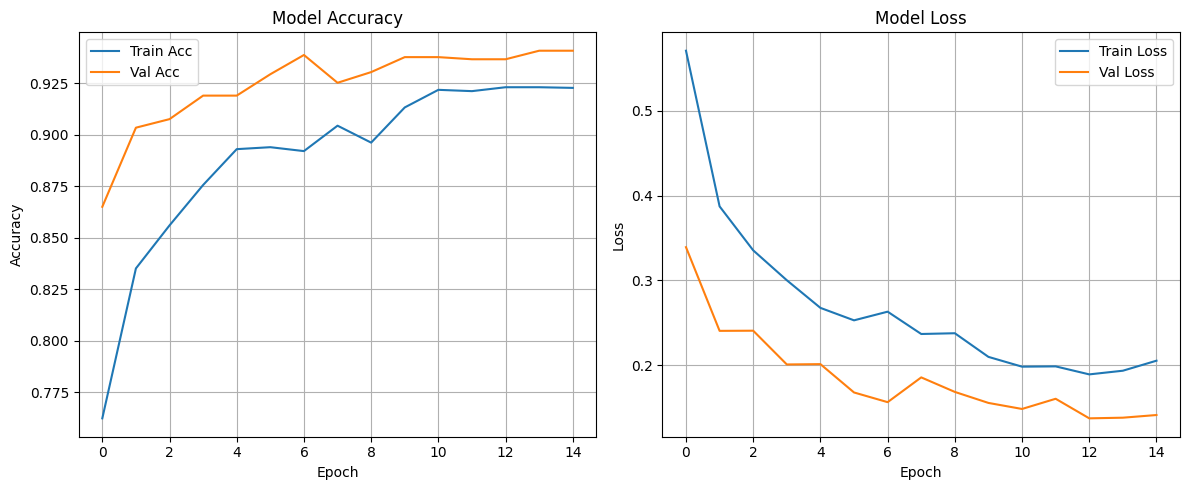

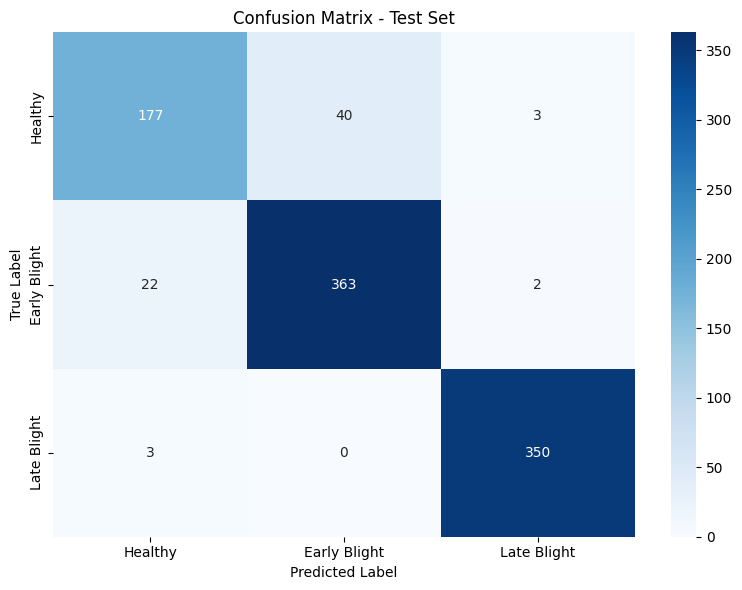


📋 Classification Report:
              precision    recall  f1-score   support

     Healthy       0.88      0.80      0.84       220
Early Blight       0.90      0.94      0.92       387
 Late Blight       0.99      0.99      0.99       353

    accuracy                           0.93       960
   macro avg       0.92      0.91      0.92       960
weighted avg       0.93      0.93      0.93       960



In [16]:
# Load best model
model = keras.models.load_model("/content/leaf-disease-project/models/best_model.h5")

# Evaluate on test set
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Precision: {test_prec*100:.2f}%")
print(f"Test Recall: {test_rec*100:.2f}%")

# Plot training curves
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/content/leaf-disease-project/results/training_curves.png", dpi=300)
plt.show()

# Confusion Matrix
Y_pred = model.predict(test_gen, verbose=0)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes_clean, yticklabels=classes_clean)
plt.title("Confusion Matrix - Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/content/leaf-disease-project/results/confusion_matrix.png", dpi=300)
plt.show()

# Classification Report
report = classification_report(y_true, y_pred, target_names=classes_clean, output_dict=True)
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes_clean))

# Save report data
with open("/content/leaf-disease-project/results/metrics.json", "w") as f:
    json.dump({
        "test_accuracy": float(test_acc),
        "test_precision": float(test_prec),
        "test_recall": float(test_rec),
        "per_class_metrics": {k: v for k,v in report.items() if k in classes_clean}
    }, f, indent=2)

In [13]:
print(type(model))
model.summary()

<class 'keras.src.models.sequential.Sequential'>


Model: "tomato_disease_detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,165 (8.93 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

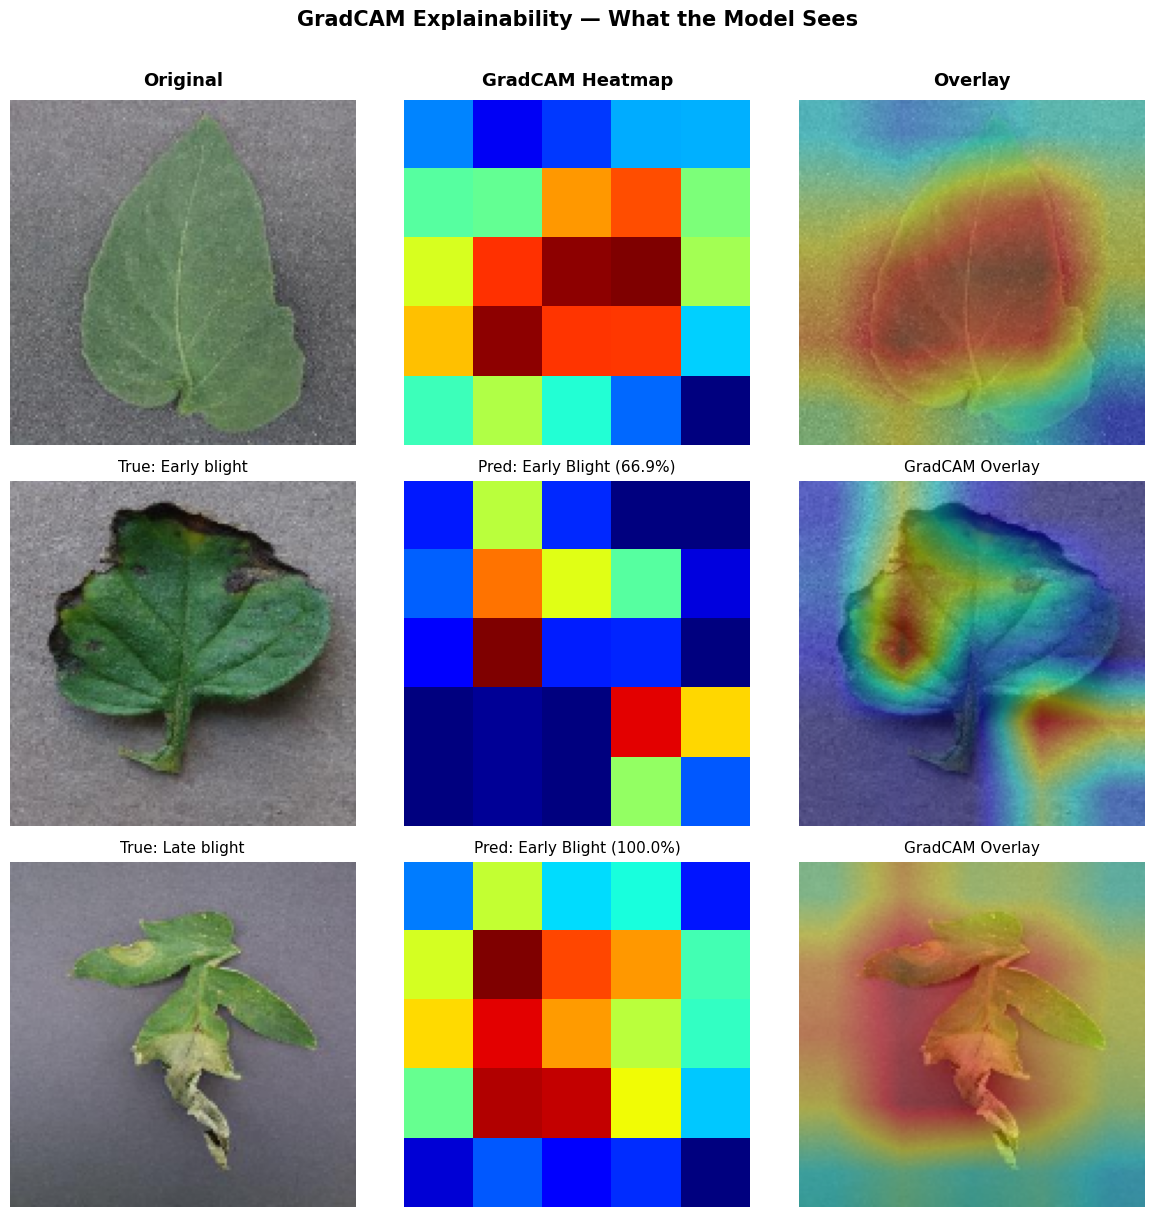

✅ GradCAM saved!


In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

def make_gradcam_heatmap(img_array, model, pred_index=None):
    """GradCAM that works with loaded .h5 Sequential + MobileNetV2."""

    # Get base model and its last conv layer
    base_model = model.get_layer("mobilenetv2_1.00_224")
    last_conv_layer = base_model.get_layer("Conv_1")

    # Build grad model using functional API — input → conv output + final output
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[last_conv_layer.output, base_model.output]
    )

    # Pass image through base model to get conv output + base output
    with tf.GradientTape() as tape:
        conv_outputs, base_out = grad_model(img_array)

        # Now pass base_out through the remaining head layers manually
        x = base_out
        for layer in model.layers[1:]:  # skip the base_model layer
            x = layer(x)

        if pred_index is None:
            pred_index = tf.argmax(x[0])

        class_channel = x[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(str(img_path))
    img = cv2.resize(img, (150, 150))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    heatmap_resized = cv2.resize(heatmap, (150, 150))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed = cv2.addWeighted(img_rgb, 1 - alpha, heatmap_colored, alpha, 0)
    return img_rgb, superimposed


# ── Plot GradCAM ─────────────────────────────────────────────────────
fig, axes = plt.subplots(len(CLASSES), 3, figsize=(12, len(CLASSES) * 4))

for row, cls in enumerate(CLASSES):
    cls_dir = PROCESSED_DIR / "test" / cls
    img_path = list(cls_dir.glob("*.JPG"))[0]

    img = keras.preprocessing.image.load_img(img_path, target_size=(150, 150))
    img_array = keras.preprocessing.image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)
    pred_class = int(np.argmax(preds[0]))
    confidence = preds[0][pred_class] * 100
    true_label = cls.replace("Tomato___", "").replace("_", " ")

    # Note: no longer passing LAST_CONV_LAYER — it's hardcoded inside the function
    heatmap = make_gradcam_heatmap(img_array, model, pred_class)
    original, overlay = overlay_gradcam(img_path, heatmap)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"True: {true_label}", fontsize=11)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heatmap, cmap="jet")
    axes[row, 1].set_title(f"Pred: {classes_clean[pred_class]} ({confidence:.1f}%)", fontsize=11)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("GradCAM Overlay", fontsize=11)
    axes[row, 2].axis("off")

for ax, title in zip(axes[0], ["Original", "GradCAM Heatmap", "Overlay"]):
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)

plt.suptitle("GradCAM Explainability — What the Model Sees", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/content/leaf-disease-project/results/gradcam_samples.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ GradCAM saved!")

In [ ]:
!apt-get install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (1,061 kB/s)
Selecting previously unselected package tree.
(Reading database ... 122363 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [19]:
!tree -L 3 /content/leaf-disease-project

/content/leaf-disease-project
├── data
│   ├── processed
│   │   ├── test
│   │   ├── train
│   │   └── val
│   └── raw
├── models
│   └── best_model.h5
├── notebooks
├── README.md
├── reports
│   └── project_report.md
├── requirements.txt
├── results
│   ├── class_distribution.png
│   ├── confusion_matrix.png
│   ├── gradcam_samples.png
│   ├── metrics.json
│   ├── sample_healthy.png
│   ├── training_curves.png
│   └── training_history.csv
└── src

11 directories, 11 files


In [ ]:
base_model = model.get_layer("mobilenetv2_1.00_224")
print([l.name for l in base_model.layers[-5:]])  # should show Conv_1, out_relu, etc.

['block_16_project', 'block_16_project_BN', 'Conv_1', 'Conv_1_bn', 'out_relu']


In [20]:
import os
os.chdir("/content/leaf-disease-project")

!git init
!git config user.email "banerjee.jalesh@gmail.com"
!git config user.name "jaleshbanerjee"

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/leaf-disease-project/.git/


In [21]:
gitignore_content = """# Data & large files
data/
*.zip
*.h5
*.hdf5

# Python
__pycache__/
*.py[cod]
*.egg-info/
.env

# Jupyter
.ipynb_checkpoints/

# OS
.DS_Store
Thumbs.db
"""

with open("/content/leaf-disease-project/.gitignore", "w") as f:
    f.write(gitignore_content)

print("✅ .gitignore created")

✅ .gitignore created


In [22]:
requirements = """tensorflow>=2.12.0
numpy>=1.23.0
pandas>=1.5.0
matplotlib>=3.6.0
scikit-learn>=1.2.0
opencv-python>=4.7.0
seaborn>=0.12.0
kaggle>=1.5.0
"""

with open("/content/leaf-disease-project/requirements.txt", "w") as f:
    f.write(requirements)

In [37]:
from google.colab import _message
print(_message.blocking_request('get_ipynb')['ipynb'])

{'nbformat': 4, 'nbformat_minor': 0, 'metadata': {'colab': {'provenance': [], 'gpuType': 'T4'}, 'kernelspec': {'name': 'python3', 'display_name': 'Python 3'}, 'language_info': {'name': 'python'}, 'accelerator': 'GPU'}, 'cells': [{'cell_type': 'code', 'execution_count': 2, 'metadata': {'id': '3S16lE3sW2te', 'executionInfo': {'status': 'ok', 'timestamp': 1779483238508, 'user_tz': -330, 'elapsed': 8328, 'user': {'displayName': 'Jalesh Banerjee', 'userId': '02984233516916782626'}}}, 'outputs': [], 'source': ['# Install required packages\n', '!pip install -q tensorflow pandas matplotlib scikit-learn opencv-python seaborn kaggle']}, {'cell_type': 'code', 'source': ['# Import libraries\n', 'import os, shutil, random, json, zipfile\n', 'import numpy as np, pandas as pd, matplotlib.pyplot as plt\n', 'import tensorflow as tf\n', 'from tensorflow import keras\n', 'from tensorflow.keras import layers, models\n', 'from tensorflow.keras.preprocessing.image import ImageDataGenerator\n', 'from tensorf